In [1]:
pip install fredapi

  Using cached fredapi-0.5.2-py3-none-any.whl.metadata (5.0 kB)
Using cached fredapi-0.5.2-py3-none-any.whl (11 kB)
Note: you may need to restart the kernel to use updated packages.


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

from fredapi import Fred

In [70]:
fred_key = 'd8ae653b3cb732c65cb18cf4c27ccfca'

# 1. Create the fred object

In [71]:
fred = Fred(api_key=fred_key)

# 2. Search for economic data

In [72]:
sp_search = fred.search('S&P', order_by='popularity')

In [73]:
sp_search.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
BAMLH0A0HYM2,BAMLH0A0HYM2,2026-02-23,2026-02-23,ICE BofA US High Yield Index Option-Adjusted S...,1996-12-31,2026-02-19,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-02-20 09:49:09-06:00,100,The ICE BofA Option-Adjusted Spreads (OASs) ar...
SP500,SP500,2026-02-23,2026-02-23,S&P 500,2016-02-22,2026-02-20,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-02-20 19:02:56-06:00,91,The observations for the S&P 500 represent the...
CSUSHPINSA,CSUSHPINSA,2026-02-23,2026-02-23,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-11-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2026-01-27 08:15:25-06:00,85,"For more information regarding the index, plea..."
BAMLC0A0CM,BAMLC0A0CM,2026-02-23,2026-02-23,ICE BofA US Corporate Index Option-Adjusted Sp...,1996-12-31,2026-02-19,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-02-20 09:50:00-06:00,85,The ICE BofA Option-Adjusted Spreads (OASs) ar...
BAMLH0A0HYM2EY,BAMLH0A0HYM2EY,2026-02-23,2026-02-23,ICE BofA US High Yield Index Effective Yield,1996-12-31,2026-02-19,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-02-20 09:48:59-06:00,85,This data represents the effective yield of th...


# 3. Pull raw data and plot

In [74]:
sp500 = fred.get_series(series_id='SP500')

<Axes: title={'center': 'S&P500'}>

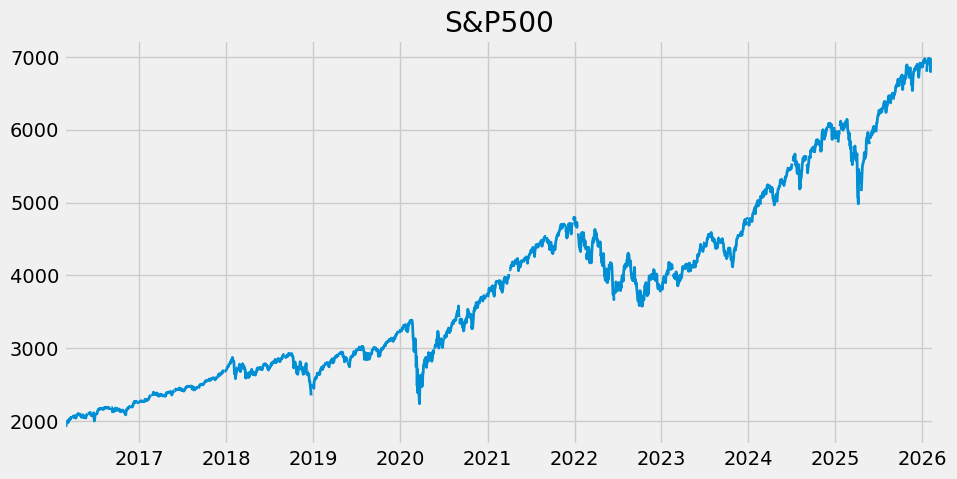

In [75]:
sp500.plot(figsize=(10,5), title='S&P500', lw=2)

# 4. Pull and join multiple data series

In [76]:
unemp_results = fred.search('unemployment')

In [77]:
unrate = fred.get_series('UNRATE')

<Axes: >

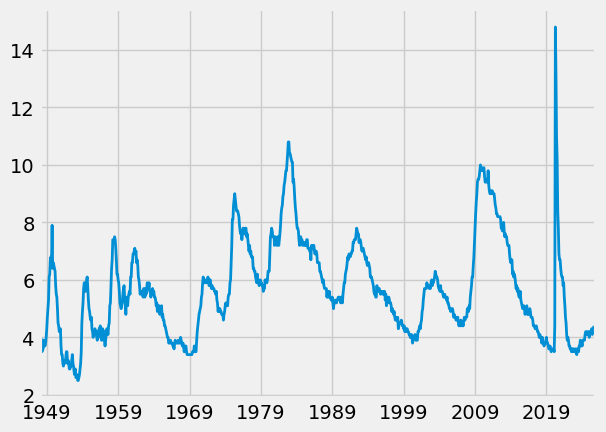

In [78]:
unrate.plot(lw=2)

In [79]:
unemp_df = fred.search('unemployment rate state', filter=('frequency', 'Monthly'))

In [80]:
unemp_df = unemp_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')

In [81]:
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')]

In [82]:
all_results = []

for myid in unemp_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)
    all_results.append(results)

In [43]:
#unemp_df.tail(2)

In [83]:
unemp_results = pd.concat(all_results, axis=1)

In [84]:
n = 4
cols_to_drop = [c for c in unemp_results.columns if len(str(c)) > n]
unemp_states = unemp_results.drop(columns=cols_to_drop)

unemp_states

,CAUR,TXUR,NYUR,FLUR,ILUR,ALUR,MIUR,NCUR,GAUR,MSUR,OHUR,VAUR,MAUR,LAUR,KYUR,AZUR,WAUR,ORUR,TNUR,NJUR,DCUR,NVUR,COUR,PAUR,MOUR,SCUR,MNUR,PRUR,WIUR,INUR,MDUR,CTUR,NMUR,WVUR,UTUR,OKUR,AKUR,ARUR
1929-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,5.6,4.1,4.2,3.9,4.4,2.8,5.1,3.7,3.4,3.8,4.8,3.5,4.7,4.4,4.7,4.2,4.5,5.2,3.6,5.2,6.2,5.3,4.1,4.1,4.1,4.4,3.7,5.7,3.1,3.7,3.8,3.8,4.1,4.0,3.4,3.2,4.7,3.9
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,5.6,4.2,4.5,4.2,4.4,2.7,5.0,3.9,3.5,3.8,4.5,3.5,4.7,4.3,4.7,4.3,4.6,5.2,3.6,5.4,6.5,5.2,3.9,4.2,4.0,4.6,4.0,5.7,3.1,3.7,4.2,4.0,4.2,4.4,3.6,3.5,4.7,4.1
2025-12-01,5.5,4.3,4.6,4.3,4.6,2.7,5.0,3.9,3.6,3.7,4.5,3.6,4.8,4.2,4.5,4.3,4.7,5.2,3.6,5.4,6.7,5.2,3.8,4.2,3.9,4.8,4.1,5.7,3.1,3.5,4.2,4.2,4.3,4.6,3.6,3.6,4.8,4.2


<Axes: >

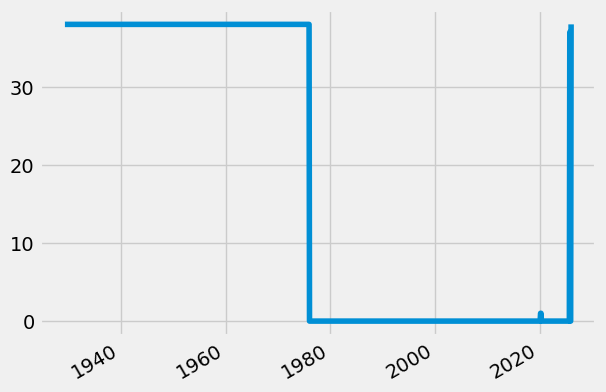

In [85]:
unemp_states.isna().sum(axis=1).plot()

In [86]:
unemp_states = unemp_states.dropna()

In [87]:
px.line(unemp_states)

# Pull April 2020 Unemployment rate per state

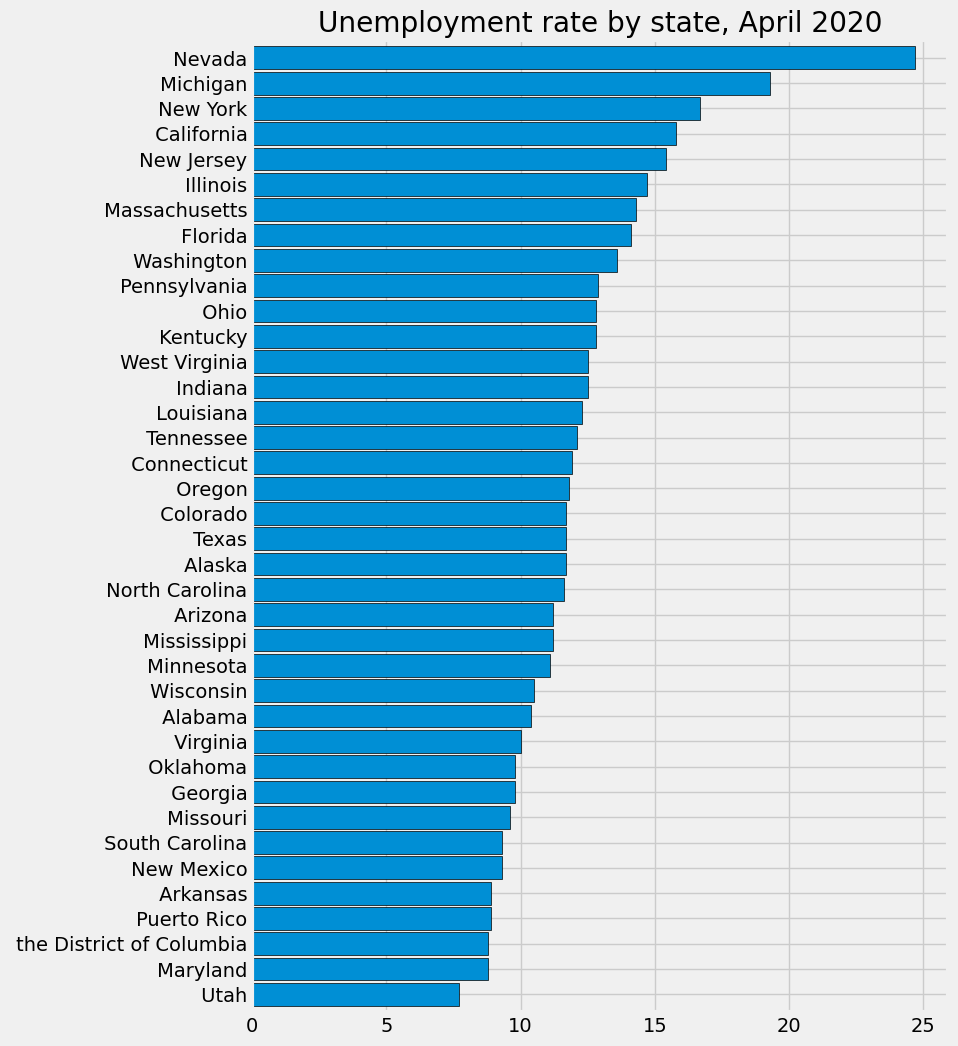

In [98]:
ax = unemp_states.loc[unemp_states.index == '2020-05-01'].T.sort_values('2020-05-01').plot(kind='barh', 
                                                                                           figsize=(8, 12), 
                                                                                           width=0.9,
                                                                                           edgecolor='black',
                                                                                           title='Unemployment rate by state, April 2020')

ax.legend().remove()

plt.show()

In [91]:
n = 4
rows_to_drop = [r for r in unemp_df.index if len(str(r)) > n]
unemp_df = unemp_df.drop(rows_to_drop, axis=0)

unemp_df

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
CAUR,CAUR,2026-02-23,2026-02-23,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,66,None
TXUR,TXUR,2026-02-23,2026-02-23,Unemployment Rate in Texas,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:48-06:00,56,None
NYUR,NYUR,2026-02-23,2026-02-23,Unemployment Rate in New York,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:51-06:00,56,None
FLUR,FLUR,2026-02-23,2026-02-23,Unemployment Rate in Florida,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:58-06:00,52,None
ILUR,ILUR,2026-02-23,2026-02-23,Unemployment Rate in Illinois,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:54-06:00,52,None
ALUR,ALUR,2026-02-23,2026-02-23,Unemployment Rate in Alabama,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:40-06:00,48,None
MIUR,MIUR,2026-02-23,2026-02-23,Unemployment Rate in Michigan,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:49-06:00,45,None
NCUR,NCUR,2026-02-23,2026-02-23,Unemployment Rate in North Carolina,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:07-06:00,39,None
GAUR,GAUR,2026-02-23,2026-02-23,Unemployment Rate in Georgia,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:15-06:00,35,None


In [93]:
id_to_state = unemp_df['title'].str.replace('Unemployment Rate in', '').to_dict()

In [94]:
unemp_states.columns = [id_to_state[c] for c in unemp_states.columns]

In [95]:
unemp_states

,California,Texas,New York,Florida,Illinois,Alabama,Michigan,North Carolina,Georgia,Mississippi,Ohio,Virginia,Massachusetts,Louisiana,Kentucky,Arizona,Washington,Oregon,Tennessee,New Jersey,the District of Columbia,Nevada,Colorado,Pennsylvania,Missouri,South Carolina,Minnesota,Puerto Rico,Wisconsin,Indiana,Maryland,Connecticut,New Mexico,West Virginia,Utah,Oklahoma,Alaska,Arkansas
1976-01-01,9.2,5.8,10.3,9.6,6.6,6.7,9.9,6.5,8.4,6.6,8.1,6.0,10.6,6.3,5.6,10.2,8.5,9.5,6.0,10.2,8.8,9.2,5.8,8.1,6.0,7.3,5.9,19.6,5.8,6.6,6.5,9.7,8.6,7.4,5.8,5.8,7.1,7.3
1976-02-01,9.2,5.8,10.3,9.7,6.6,6.6,9.9,6.5,8.4,6.6,8.1,6.0,10.6,6.3,5.6,10.2,8.5,9.5,6.0,10.2,8.8,9.2,5.8,8.1,6.0,7.3,5.9,19.5,5.8,6.6,6.5,9.7,8.6,7.4,5.9,5.8,7.1,7.3
1976-03-01,9.1,5.9,10.2,9.6,6.6,6.6,9.9,6.5,8.3,6.6,8.1,6.0,10.6,6.3,5.6,10.2,8.5,9.4,6.0,10.2,8.7,9.2,5.7,8.1,6.0,7.3,5.8,19.3,5.8,6.5,6.5,9.7,8.6,7.4,5.8,5.8,7.0,7.3
1976-04-01,9.0,5.9,10.2,9.5,6.6,6.5,9.8,6.3,8.2,6.4,7.9,5.9,10.4,6.4,5.6,10.0,8.5,9.3,6.0,10.3,8.6,9.0,5.6,8.1,6.0,7.1,5.7,19.0,5.7,6.3,6.5,9.6,8.6,7.4,5.8,5.7,7.0,7.2
1976-05-01,8.9,6.0,10.2,9.3,6.6,6.4,9.6,6.1,8.1,6.3,7.8,5.8,10.1,6.5,5.5,9.8,8.5,9.1,5.9,10.3,8.5,8.8,5.6,8.1,6.0,7.0,5.6,18.9,5.6,6.0,6.6,9.4,8.6,7.4,5.7,5.7,7.0,7.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-01,5.5,4.0,4.0,3.7,4.6,3.0,5.3,3.7,3.4,3.9,5.0,3.6,4.8,4.5,4.9,4.1,4.5,4.9,3.6,4.9,6.0,5.4,4.5,4.0,4.1,4.2,3.5,5.5,3.1,3.6,3.4,3.8,4.2,3.7,3.3,3.1,4.8,3.7
2025-08-01,5.5,4.1,4.0,3.8,4.4,2.9,5.2,3.7,3.4,3.9,5.0,3.6,4.8,4.4,4.7,4.1,4.5,5.0,3.6,5.0,6.0,5.3,4.2,4.0,4.1,4.3,3.6,5.6,3.1,3.6,3.6,3.8,4.1,3.8,3.3,3.1,4.7,3.8
2025-09-01,5.6,4.1,4.2,3.9,4.4,2.8,5.1,3.7,3.4,3.8,4.8,3.5,4.7,4.4,4.7,4.2,4.5,5.2,3.6,5.2,6.2,5.3,4.1,4.1,4.1,4.4,3.7,5.7,3.1,3.7,3.8,3.8,4.1,4.0,3.4,3.2,4.7,3.9
2025-11-01,5.6,4.2,4.5,4.2,4.4,2.7,5.0,3.9,3.5,3.8,4.5,3.5,4.7,4.3,4.7,4.3,4.6,5.2,3.6,5.4,6.5,5.2,3.9,4.2,4.0,4.6,4.0,5.7,3.1,3.7,4.2,4.0,4.2,4.4,3.6,3.5,4.7,4.1


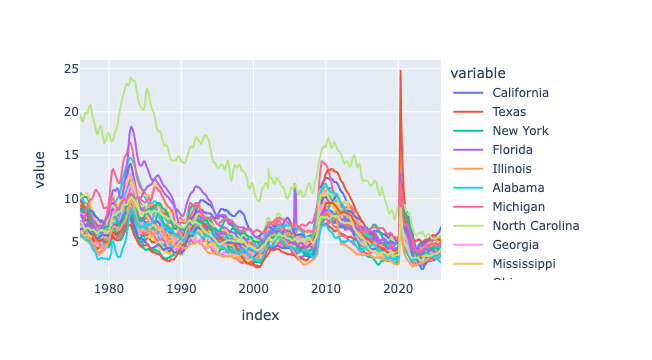

In [96]:
px.line(unemp_states)

# Pull Participation rate

In [124]:
part_df = fred.search('tax rate state', filter=('frequency', 'Monthly'))
part_df = part_df.query('seasonal_adjustment == "Seasonally Adjusted Annual Rate" and units == "Percent per Annum"')

In [125]:
part_df

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
PSAVERT,PSAVERT,2026-02-23,2026-02-23,Personal Saving Rate,1959-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted Annual Rate,SAAR,2026-02-20 07:43:48-06:00,82,BEA Account Code: A072RC Personal saving as a ...
M1329BUSM193NNBR,M1329BUSM193NNBR,2026-02-23,2026-02-23,"Yields on Short-Term United States Securities,...",1931-01-01,1969-11-01,Monthly,M,Percent per Annum,% per Annum,Not Seasonally Adjusted,NSA,2012-08-20 08:18:12-05:00,10,Series Is Presented Here As Two Variables--(1)...
CROASMIDTIER,CROASMIDTIER,2026-02-23,2026-02-23,"AD&Co US Mortgage High Yield Index, Credit-and...",2015-06-01,2026-01-01,Monthly,M,Index,Index,Not Seasonally Adjusted,NSA,2026-02-12 09:49:16-06:00,44,"The AD&Co US Mortgage High Yield Index crOAS, ..."
W055RC1,W055RC1,2026-02-23,2026-02-23,Personal current taxes,1959-01-01,2025-12-01,Monthly,M,Billions of Dollars,Bil. of $,Seasonally Adjusted Annual Rate,SAAR,2026-02-20 07:43:46-06:00,18,BEA Account Code: W055RC A Guide to the Nation...
M1333AUSM156NNBR,M1333AUSM156NNBR,2026-02-23,2026-02-23,Yield on Long-Term United States Bonds for Uni...,1919-01-01,1944-02-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2012-08-20 08:17:48-05:00,20,Series Is Presented Here As Two Variables--(1)...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
APU0100717412,APU0100717412,2026-02-23,2026-02-23,"Average Price: Coffee, Instant, Plain, 3.1-6 O...",1980-01-01,1980-08-01,Monthly,M,U.S. Dollars,U.S. $,Not Seasonally Adjusted,NSA,2019-07-29 09:34:34-05:00,1,Average consumer prices are calculated for hou...
APU0300717325,APU0300717325,2026-02-23,2026-02-23,"Average Price: Coffee, Freeze Dried, Regular, ...",1987-01-01,1988-03-01,Monthly,M,U.S. Dollars,U.S. $,Not Seasonally Adjusted,NSA,2019-07-29 09:31:47-05:00,1,Average consumer prices are calculated for hou...
APU0300717312,APU0300717312,2026-02-23,2026-02-23,"Average Price: Coffee, 100%, Ground Roast, 13....",1980-01-01,1988-08-01,Monthly,M,U.S. Dollars,U.S. $,Not Seasonally Adjusted,NSA,2019-07-29 09:31:48-05:00,1,100% ground coffee only in 13.1 - 20 oz. cans....
